In [15]:
import pandas as pd
import numpy as np
import xgboost as xgb
import joblib
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import warnings
warnings.filterwarnings('ignore')

path = r"C:\Users\Arifi\Desktop\FORECASTING OBAT\data\final\dataset_xgboost_ready.csv"
dataset = pd.read_csv(path)
dataset['Tanggal'] = pd.to_datetime(dataset['Tanggal'])
best_params = pd.read_csv(r'C:\Users\Arifi\Desktop\FORECASTING OBAT\data\final\best_params.csv').to_dict(orient='records')[0]
best_params['n_estimators'] = int(best_params['n_estimators'])
best_params['max_depth']    = int(best_params['max_depth'])

FEATURES = ['Lag_1', 'Lag_2', 'Lag_3', 'Lag_4',
            'Rolling_Mean_4', 'Bulan', 'Pekan_Ke', 'Rata_Historis_SKU']
TARGET = 'Jumlah'

all_weeks = sorted(dataset['Tanggal'].unique())
INIT_TRAIN = 40
HORIZON    = 12

print(f"Total minggu : {len(all_weeks)}")
print(f"Train awal   : {INIT_TRAIN} minggu")
print(f"Horizon      : {HORIZON} minggu")
print(f"Evaluasi     : minggu {INIT_TRAIN+1} s/d {INIT_TRAIN+HORIZON}")

Total minggu : 53
Train awal   : 40 minggu
Horizon      : 12 minggu
Evaluasi     : minggu 41 s/d 52


In [16]:
wf_results = []

for i in range(HORIZON):
    test_week  = all_weeks[INIT_TRAIN + i]
    train_data = dataset[dataset['Tanggal'] < test_week]
    test_data  = dataset[dataset['Tanggal'] == test_week]

    model = xgb.XGBRegressor(**best_params)
    model.fit(train_data[FEATURES], train_data[TARGET], verbose=False)

    pred   = model.predict(test_data[FEATURES])
    actual = test_data[TARGET].values

    rmse = np.sqrt(mean_squared_error(actual, pred))
    mae  = mean_absolute_error(actual, pred)
    r2   = r2_score(actual, pred)

    wf_results.append({
        'Iterasi':     i + 1,
        'Minggu':      test_week,
        'Train_Weeks': INIT_TRAIN + i,
        'RMSE':        round(rmse, 4),
        'MAE':         round(mae, 4),
        'R2':          round(r2, 4)
    })
    print(f"Iter {i+1:02d} | Train: {INIT_TRAIN+i} minggu | RMSE: {rmse:.4f} | MAE: {mae:.4f} | R²: {r2:.4f}")

wf_df = pd.DataFrame(wf_results)

Iter 01 | Train: 40 minggu | RMSE: 10.0013 | MAE: 5.2097 | R²: 0.3196
Iter 02 | Train: 41 minggu | RMSE: 11.0068 | MAE: 5.6579 | R²: 0.2190
Iter 03 | Train: 42 minggu | RMSE: 8.8447 | MAE: 5.0076 | R²: 0.3305
Iter 04 | Train: 43 minggu | RMSE: 10.3719 | MAE: 5.6649 | R²: 0.3690
Iter 05 | Train: 44 minggu | RMSE: 10.4495 | MAE: 5.8813 | R²: 0.2827
Iter 06 | Train: 45 minggu | RMSE: 9.2953 | MAE: 4.8580 | R²: 0.4101
Iter 07 | Train: 46 minggu | RMSE: 7.9784 | MAE: 4.9620 | R²: 0.1619
Iter 08 | Train: 47 minggu | RMSE: 13.9217 | MAE: 6.3121 | R²: 0.3703
Iter 09 | Train: 48 minggu | RMSE: 11.5865 | MAE: 5.5136 | R²: 0.3886
Iter 10 | Train: 49 minggu | RMSE: 14.3639 | MAE: 6.7863 | R²: 0.4173
Iter 11 | Train: 50 minggu | RMSE: 7.8122 | MAE: 4.6590 | R²: 0.5870
Iter 12 | Train: 51 minggu | RMSE: 11.3054 | MAE: 5.7629 | R²: 0.4938


In [17]:
ma4_results = []

for i in range(HORIZON):
    test_week = all_weeks[INIT_TRAIN + i]
    test_data = dataset[dataset['Tanggal'] == test_week]

    pred_ma4 = test_data['Rolling_Mean_4'].values
    actual   = test_data[TARGET].values

    rmse = np.sqrt(mean_squared_error(actual, pred_ma4))
    mae  = mean_absolute_error(actual, pred_ma4)

    ma4_results.append({
        'Iterasi':  i + 1,
        'RMSE_MA4': round(rmse, 4),
        'MAE_MA4':  round(mae, 4)
    })

ma4_df = pd.DataFrame(ma4_results)

In [18]:
compare = wf_df.merge(ma4_df, on='Iterasi')
compare['XGB_Menang'] = compare['RMSE'] < compare['RMSE_MA4']

print("=== WALK-FORWARD VALIDATION: XGBoost vs MA-4 ===")
cols = ['Iterasi','Minggu','RMSE','RMSE_MA4','MAE','MAE_MA4','XGB_Menang']
print(compare[cols].to_string(index=False))
print()
print(f"Rata-rata RMSE XGBoost : {compare['RMSE'].mean():.4f}")
print(f"Rata-rata RMSE MA-4    : {compare['RMSE_MA4'].mean():.4f}")
print(f"Rata-rata MAE  XGBoost : {compare['MAE'].mean():.4f}")
print(f"Rata-rata MAE  MA-4    : {compare['MAE_MA4'].mean():.4f}")
print(f"Rata-rata R²  XGBoost  : {wf_df['R2'].mean():.4f}")
print(f"\nXGBoost unggul di {compare['XGB_Menang'].sum()} dari {HORIZON} iterasi")

=== WALK-FORWARD VALIDATION: XGBoost vs MA-4 ===
 Iterasi     Minggu    RMSE  RMSE_MA4    MAE  MAE_MA4  XGB_Menang
       1 2026-02-03 10.0013   11.3192 5.2097   4.7776        True
       2 2026-02-10 11.0068   11.7789 5.6579   5.4538        True
       3 2026-02-17  8.8447    9.0929 5.0076   4.3737        True
       4 2026-02-24 10.3719   10.7467 5.6649   5.2679        True
       5 2026-03-03 10.4495   12.2507 5.8813   5.4295        True
       6 2026-03-10  9.2953    9.8971 4.8580   4.5218        True
       7 2026-03-17  7.9784    8.8506 4.9620   4.2551        True
       8 2026-03-24 13.9217   13.1117 6.3121   5.6256       False
       9 2026-03-31 11.5865   12.3406 5.5136   5.0583        True
      10 2026-04-07 14.3639   15.3356 6.7863   6.0327        True
      11 2026-04-14  7.8122    9.4549 4.6590   4.4558        True
      12 2026-04-21 11.3054   12.4286 5.7629   5.4487        True

Rata-rata RMSE XGBoost : 10.5781
Rata-rata RMSE MA-4    : 11.3840
Rata-rata MAE  XGBoost : 5

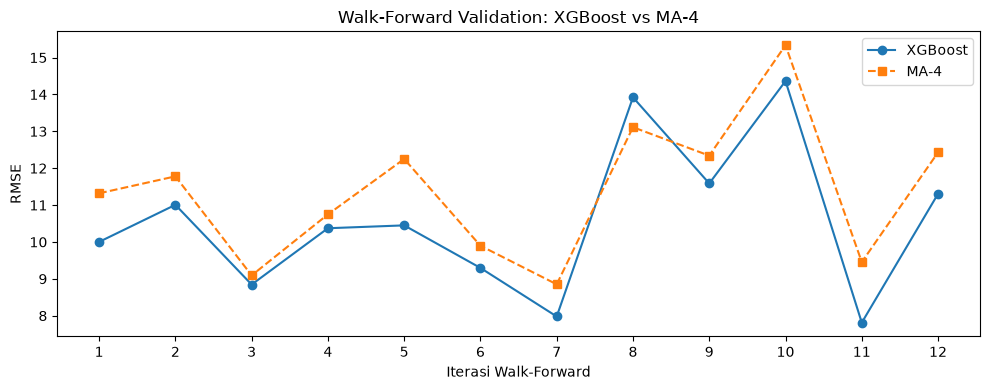

In [19]:
plt.figure(figsize=(10, 4))
plt.plot(compare['Iterasi'], compare['RMSE'],     marker='o', label='XGBoost')
plt.plot(compare['Iterasi'], compare['RMSE_MA4'], marker='s', linestyle='--', label='MA-4')
plt.xlabel('Iterasi Walk-Forward')
plt.ylabel('RMSE')
plt.title('Walk-Forward Validation: XGBoost vs MA-4')
plt.legend()
plt.xticks(range(1, HORIZON + 1))
plt.tight_layout()
plt.show()

In [20]:
final_model = joblib.load(r'C:\Users\Arifi\Desktop\FORECASTING OBAT\models\xgboost_best_model.joblib')
eval_weeks  = all_weeks[INIT_TRAIN: INIT_TRAIN + HORIZON]
sku_results = []

for sku in dataset['Kode Produk'].unique():
    sku_data = dataset[
        (dataset['Kode Produk'] == sku) &
        (dataset['Tanggal'].isin(eval_weeks))
    ].sort_values('Tanggal')

    if len(sku_data) < 6:
        continue

    actual   = sku_data[TARGET].values
    pred_xgb = final_model.predict(sku_data[FEATURES])
    pred_ma4 = sku_data['Rolling_Mean_4'].values

    mae_xgb  = mean_absolute_error(actual, pred_xgb)
    mae_ma4  = mean_absolute_error(actual, pred_ma4)
    rmse_xgb = np.sqrt(mean_squared_error(actual, pred_xgb))
    rmse_ma4 = np.sqrt(mean_squared_error(actual, pred_ma4))

    engine = 'XGBoost' if rmse_xgb < rmse_ma4 else 'MA-4'

    sku_results.append({
        'Kode Produk':  sku,
        'MAE_XGBoost':  round(mae_xgb, 4),
        'MAE_MA4':      round(mae_ma4, 4),
        'RMSE_XGBoost': round(rmse_xgb, 4),
        'RMSE_MA4':     round(rmse_ma4, 4),
        'Engine':       engine
    })

sku_df = pd.DataFrame(sku_results)
print("=== ENGINE ASSIGNMENT PER SKU ===")
print(sku_df['Engine'].value_counts())
print(f"Total SKU terevaluasi: {len(sku_df)}")
print("Engine assignment berdasarkan RMSE")

print(
    sku_df['Engine'].value_counts()
)

print(
    "Total SKU evaluated:",
    len(sku_df)
)

=== ENGINE ASSIGNMENT PER SKU ===
Engine
MA-4       138
XGBoost     57
Name: count, dtype: int64
Total SKU terevaluasi: 195
Engine assignment berdasarkan RMSE
Engine
MA-4       138
XGBoost     57
Name: count, dtype: int64
Total SKU evaluated: 195


SKU representatif: OB-GRA4MG


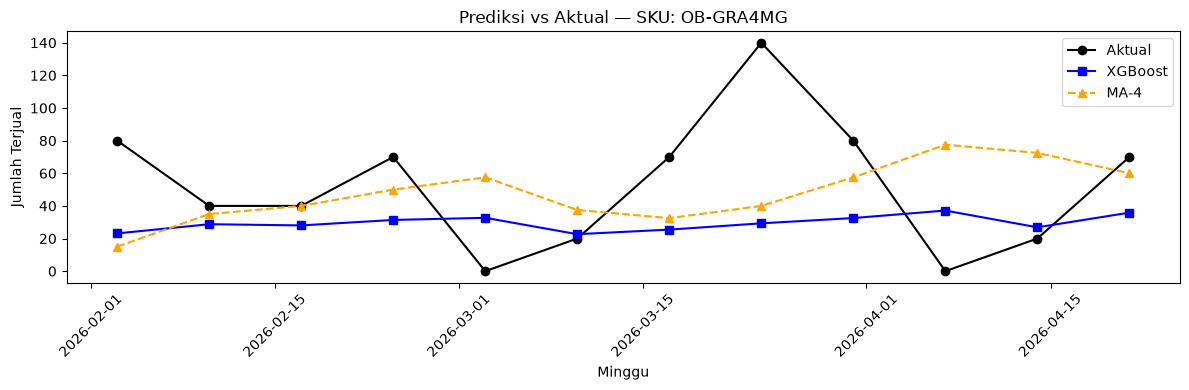

RMSE XGBoost : 45.7770
RMSE MA-4    : 49.1914


In [21]:
# Ambil SKU dengan volume tertinggi di periode evaluasi
eval_weeks = all_weeks[INIT_TRAIN: INIT_TRAIN + HORIZON]

volume_per_sku = dataset[dataset['Tanggal'].isin(eval_weeks)].groupby('Kode Produk')[TARGET].sum()
sku_rep = volume_per_sku.idxmax()
print(f"SKU representatif: {sku_rep}")

sku_data = dataset[
    (dataset['Kode Produk'] == sku_rep) &
    (dataset['Tanggal'].isin(eval_weeks))
].sort_values('Tanggal')

actual   = sku_data[TARGET].values
pred_xgb = final_model.predict(sku_data[FEATURES])
pred_ma4 = sku_data['Rolling_Mean_4'].values
minggu   = sku_data['Tanggal'].values

plt.figure(figsize=(12, 4))
plt.plot(minggu, actual,   marker='o', color='black',  label='Aktual')
plt.plot(minggu, pred_xgb, marker='s', color='blue',   label='XGBoost')
plt.plot(minggu, pred_ma4, marker='^', color='orange', linestyle='--', label='MA-4')
plt.title(f'Prediksi vs Aktual — SKU: {sku_rep}')
plt.xlabel('Minggu')
plt.ylabel('Jumlah Terjual')
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

rmse_xgb = np.sqrt(mean_squared_error(actual, pred_xgb))
rmse_ma4 = np.sqrt(mean_squared_error(actual, pred_ma4))

print(f"RMSE XGBoost : {rmse_xgb:.4f}")
print(f"RMSE MA-4    : {rmse_ma4:.4f}")

In [22]:
sku_df.to_csv(r'C:\Users\Arifi\Desktop\FORECASTING OBAT\data\final\sku_evaluation.csv', index=False)
wf_df.to_csv(r'C:\Users\Arifi\Desktop\FORECASTING OBAT\data\final\walkforward_results.csv', index=False)
print("Tersimpan: sku_evaluation.csv, walkforward_results.csv")

Tersimpan: sku_evaluation.csv, walkforward_results.csv
